Mounted at /content/drive

Feature columns: ['Ia', 'Ib', 'Ic', 'THD_Ia', 'THD_Ib', 'THD_Ic', 'Displacement', 'Velocity', 'Acceleration', 'Hot Spot']
Number of features: 10

Label columns: ['Fault', 'FaultL', 'FaultP', 'LoopI']

Unique values in Fault: [0 1]

Unique values in FaultL: [0 1 2 3 4]

Unique values in FaultP: [0 1 3]

Unique values in LoopI: [0.  0.4 0.6 1.2 2.  0.2 1.4 8.4 8.2]

Training models...

Training classification models for Fault...
Training lr model...
Training rf model...
Training nn model...
Training svm model...
Training knn model...

Training classification models for FaultL...
Training lr model...
Training rf model...
Training nn model...
Training svm model...
Training knn model...

Training classification models for FaultP...
Training lr model...
Training rf model...
Training nn model...
Training svm model...
Training knn model...

Training regression models for LoopI...
Training lr model...
Training rf model...
Training nn model...
Training svm model...
Tra

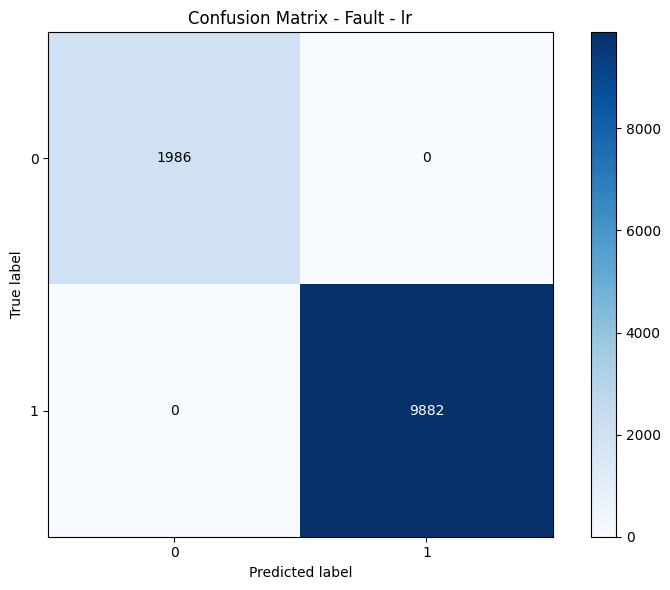


RF Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0]
 [   0 9882]]


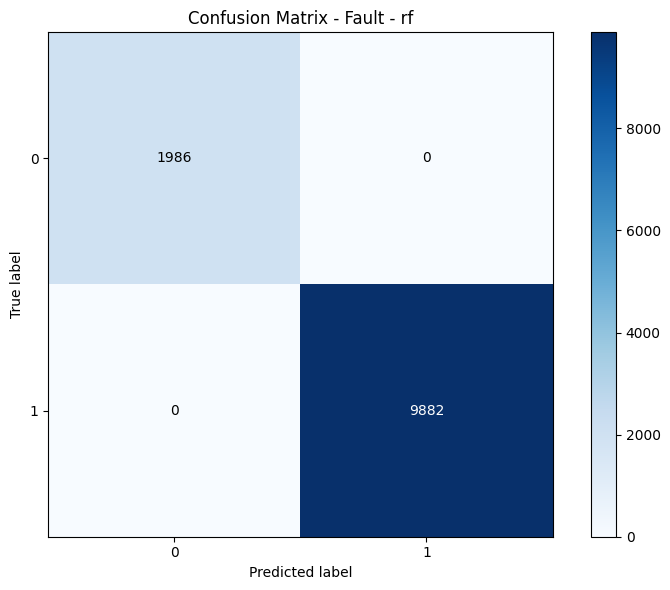


NN Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0]
 [   0 9882]]


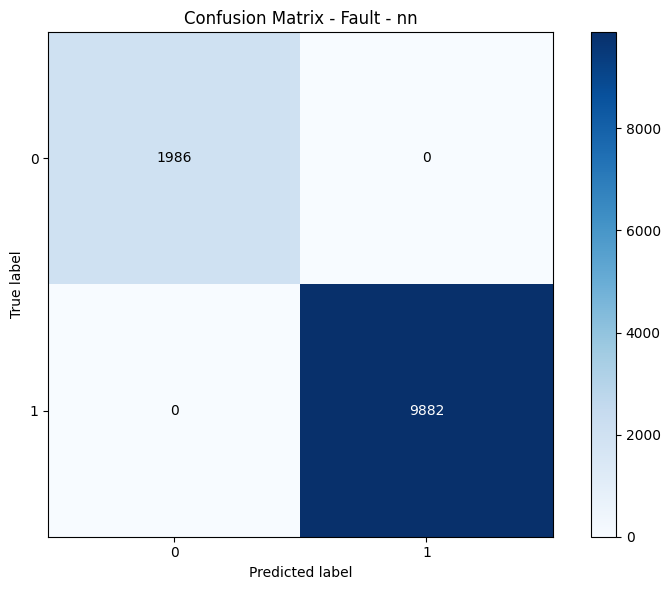


SVM Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0]
 [   0 9882]]


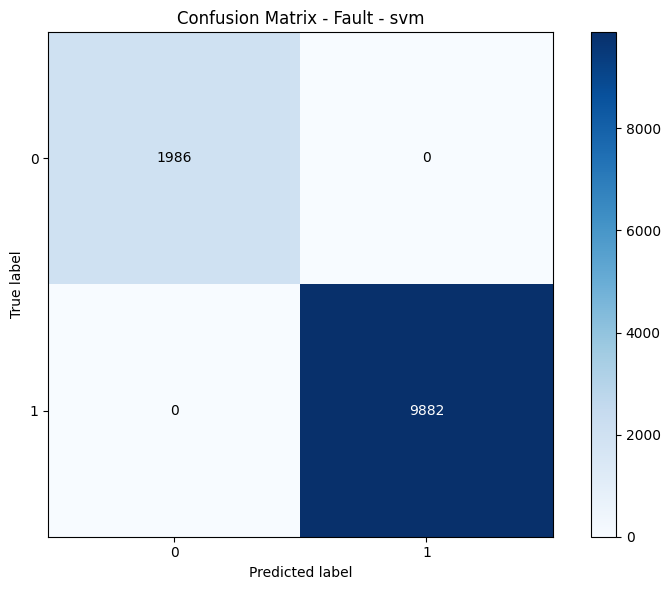


KNN Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0]
 [   0 9882]]


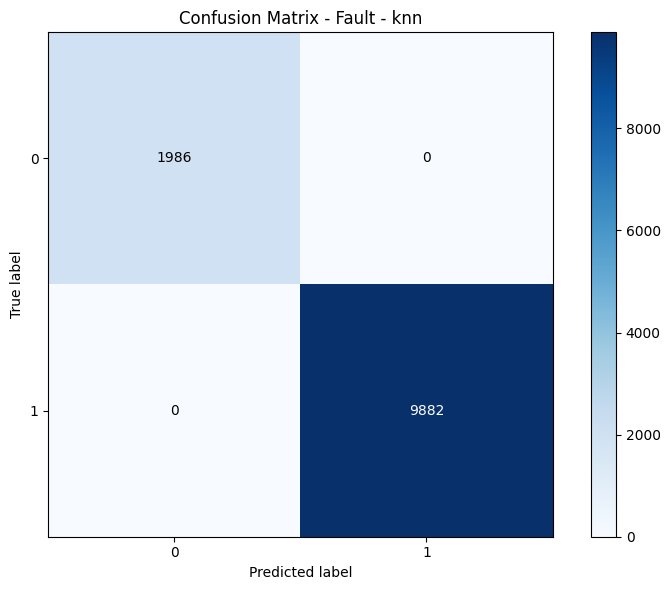


Evaluating classification models for FaultL...

LR Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0    0    0    0]
 [   0 1976    0    0    0]
 [   0    0 2955    0    0]
 [   0    0    0 1974    0]
 [   0    0    0    0 2977]]


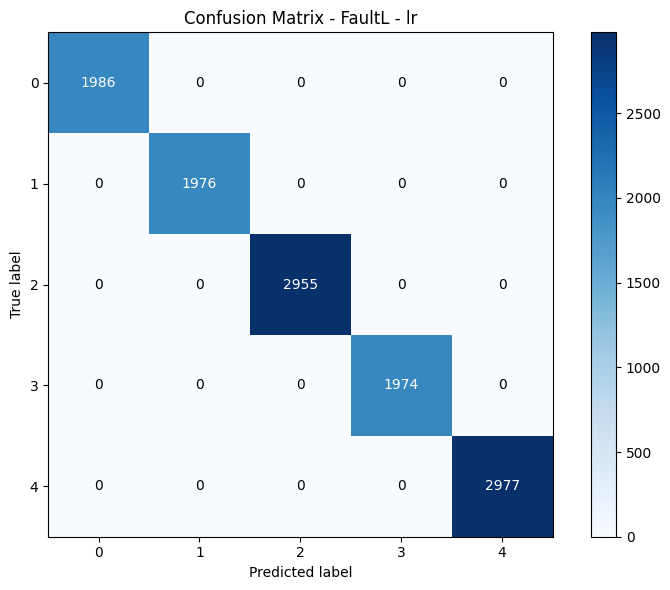


RF Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0    0    0    0]
 [   0 1976    0    0    0]
 [   0    0 2955    0    0]
 [   0    0    0 1974    0]
 [   0    0    0    0 2977]]


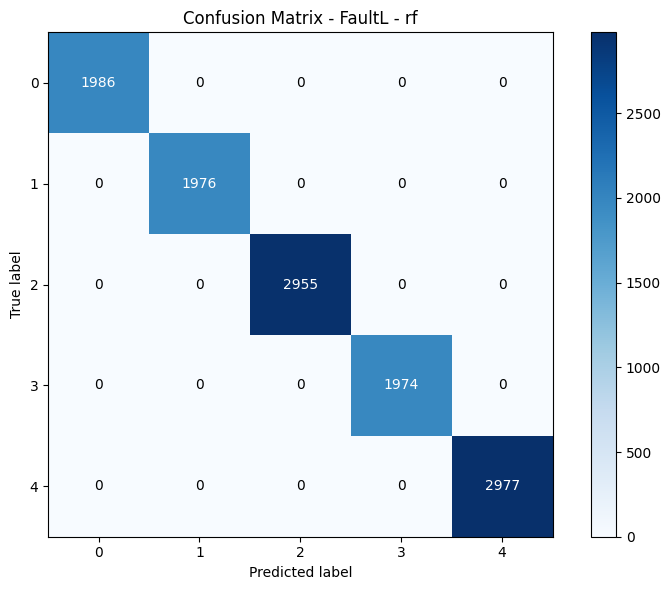


NN Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0    0    0    0]
 [   0 1976    0    0    0]
 [   0    0 2955    0    0]
 [   0    0    0 1974    0]
 [   0    0    0    0 2977]]


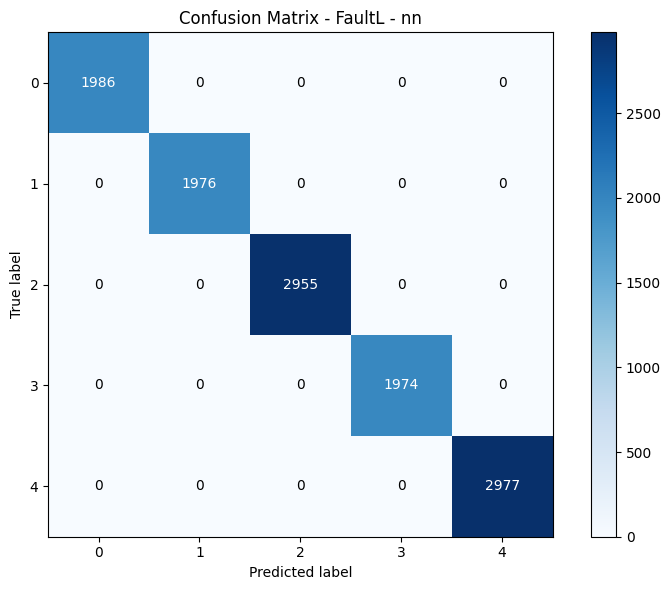


SVM Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0    0    0    0]
 [   0 1976    0    0    0]
 [   0    0 2955    0    0]
 [   0    0    0 1974    0]
 [   0    0    0    0 2977]]


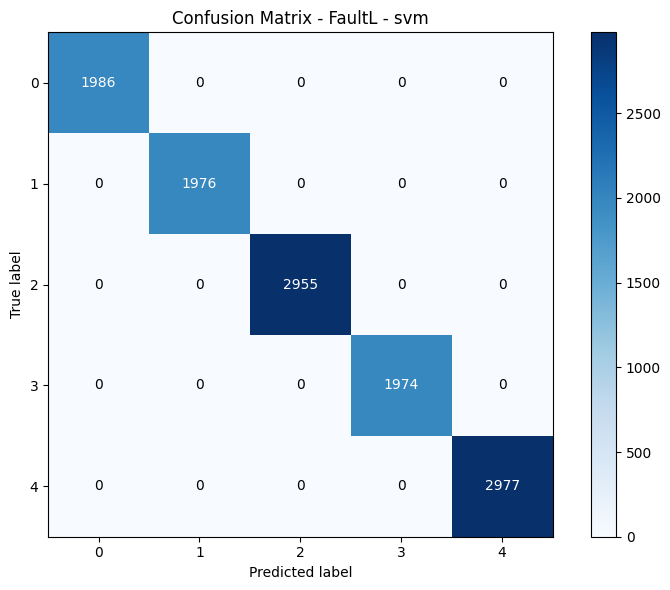


KNN Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0    0    0    0]
 [   0 1976    0    0    0]
 [   0    0 2955    0    0]
 [   0    0    0 1974    0]
 [   0    0    0    0 2977]]


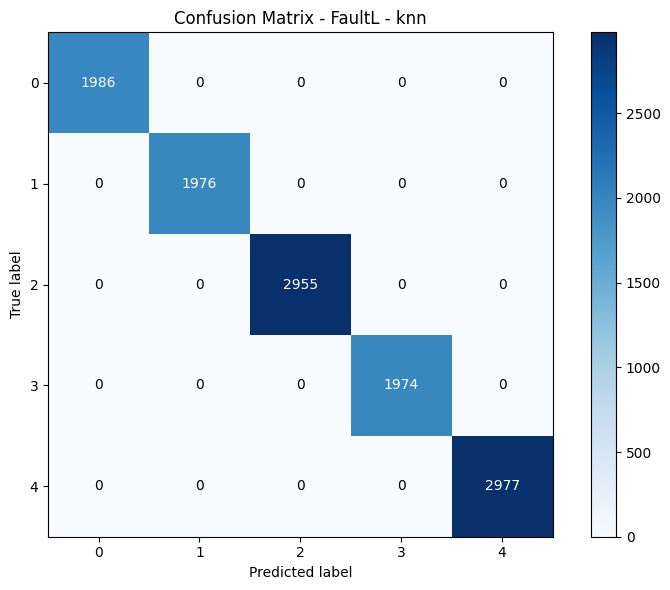


Evaluating classification models for FaultP...

LR Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0    0]
 [   0 7905    0]
 [   0    0 1977]]


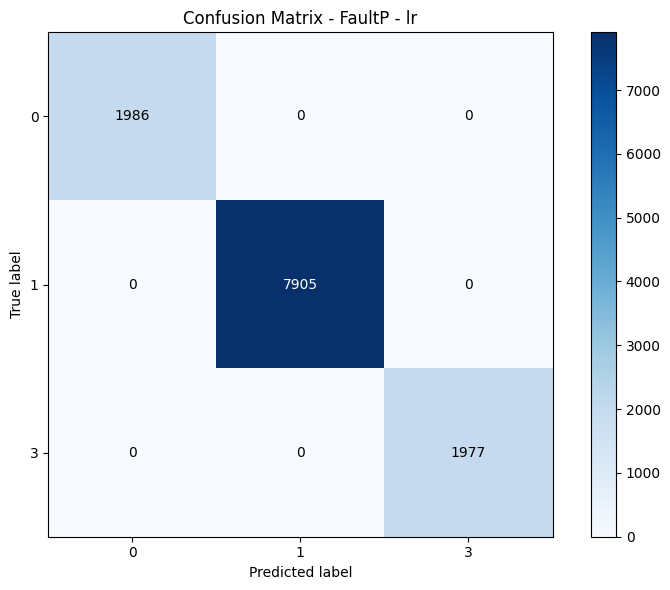


RF Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0    0]
 [   0 7905    0]
 [   0    0 1977]]


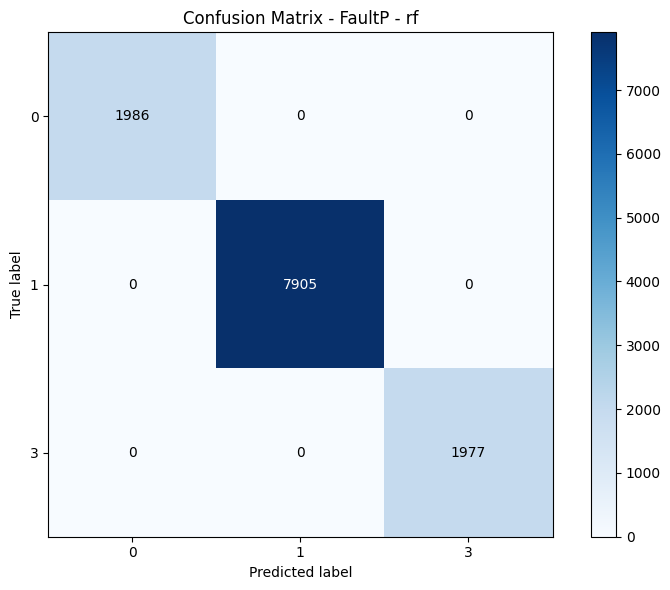


NN Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0    0]
 [   0 7905    0]
 [   0    0 1977]]


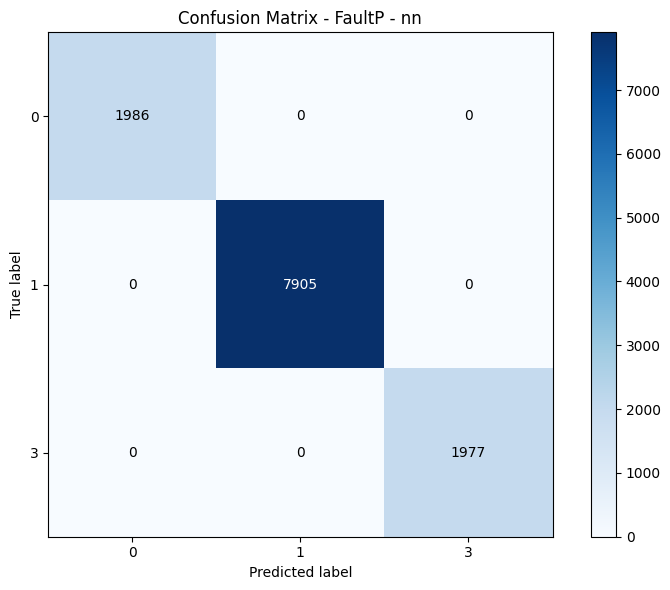


SVM Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0    0]
 [   0 7905    0]
 [   0    0 1977]]


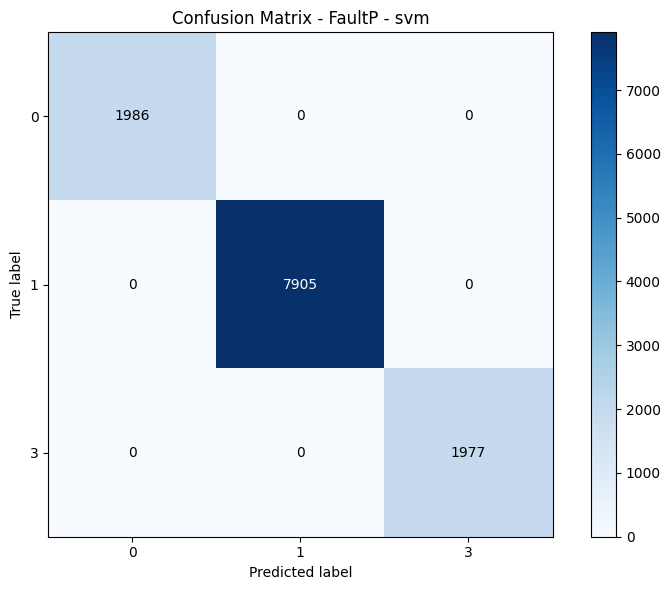


KNN Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0    0]
 [   0 7905    0]
 [   0    0 1977]]


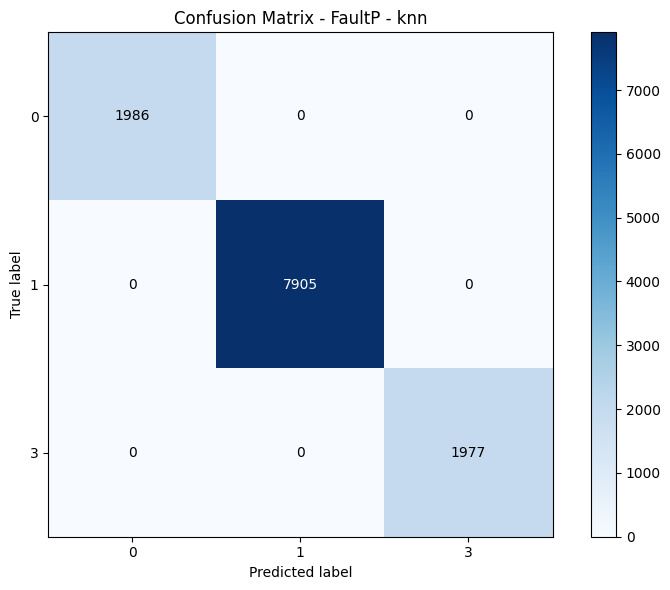


Evaluating regression models for LoopI...

LR Model:
Mean Squared Error: 0.02
R-squared: 1.00


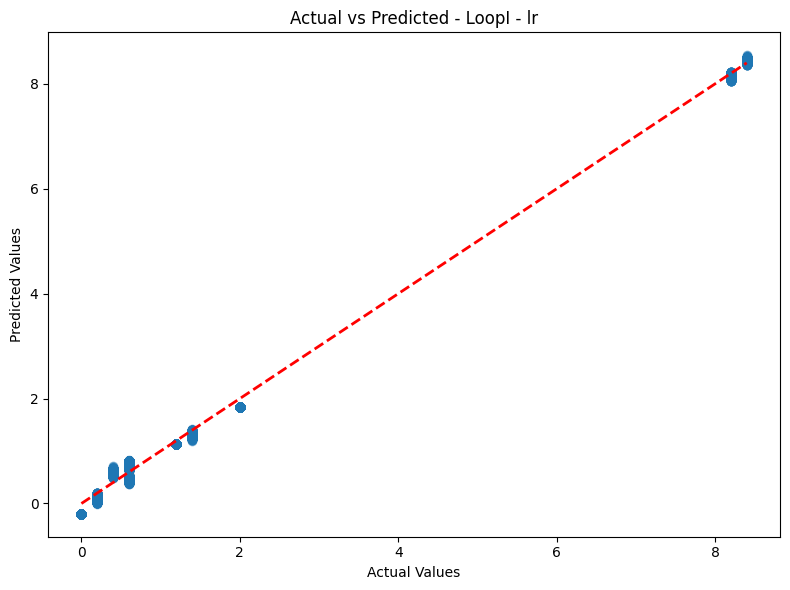


RF Model:
Mean Squared Error: 0.00
R-squared: 1.00


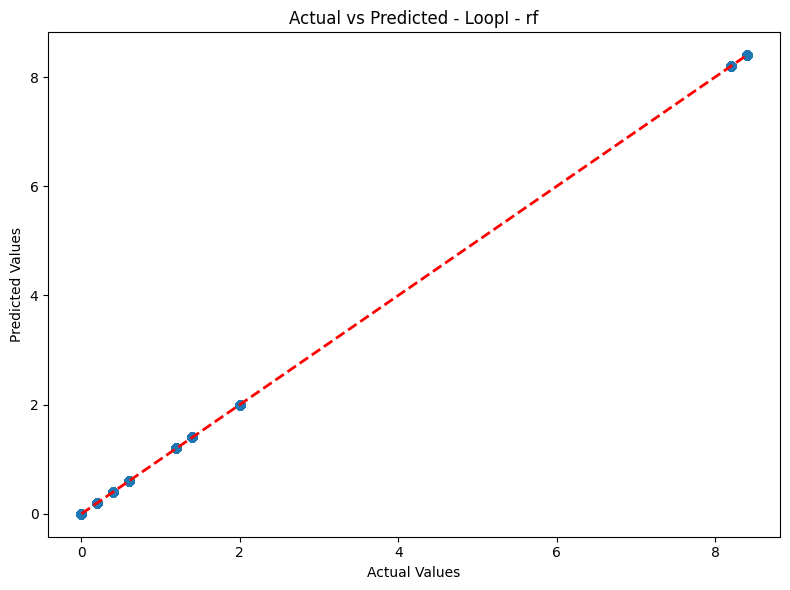


NN Model:
Mean Squared Error: 0.00
R-squared: 1.00


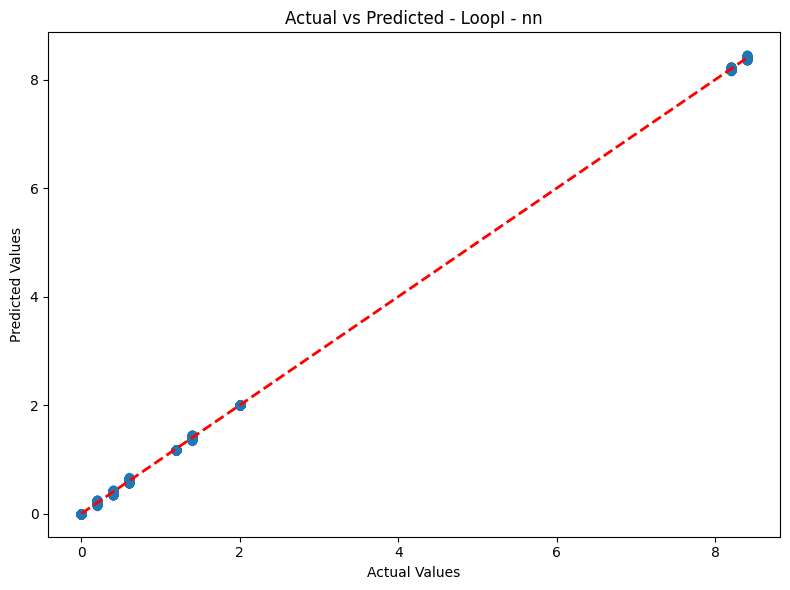


SVM Model:
Mean Squared Error: 0.01
R-squared: 1.00


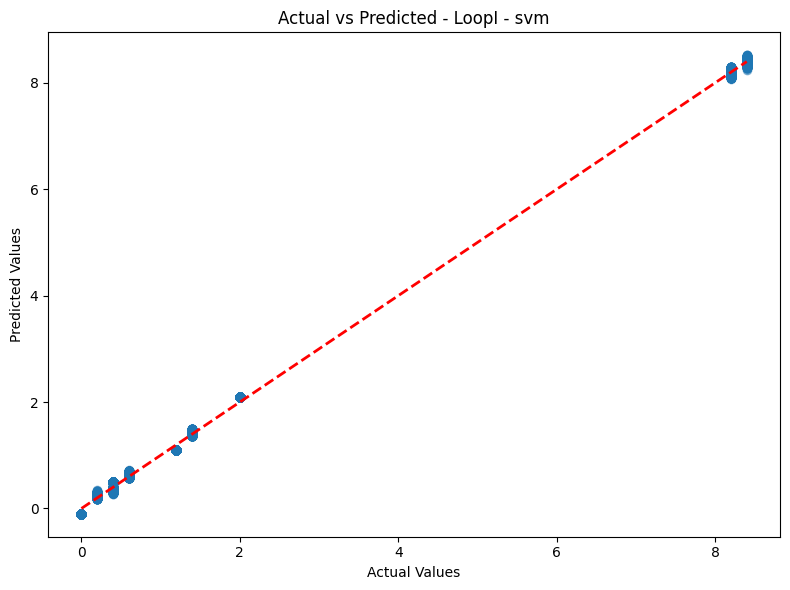


KNN Model:
Mean Squared Error: 0.00
R-squared: 1.00


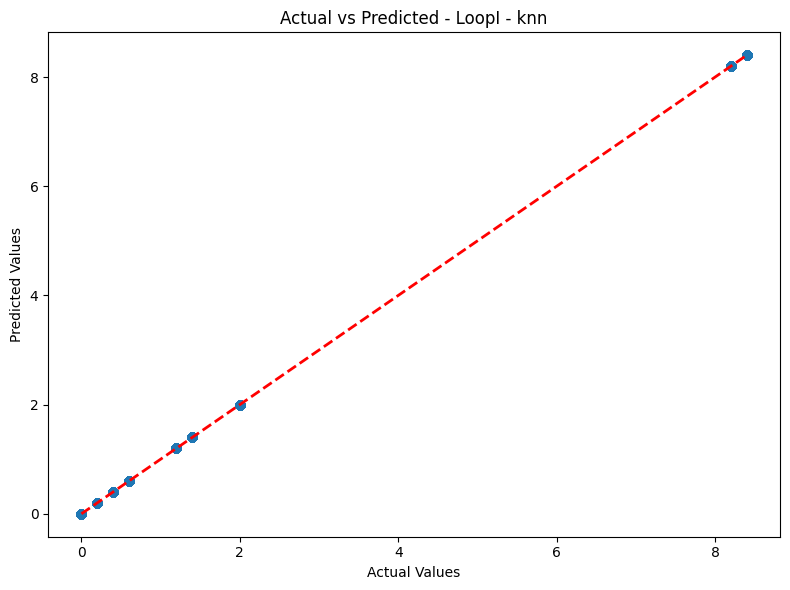

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from google.colab import drive
from joblib import dump, load

def load_data_from_drive(file_path):
    """
    Load data and separate features and labels
    """
    try:
        drive.mount('/content/drive')

        if file_path.endswith('.xlsx'):
            df = pd.read_excel(file_path)
        elif file_path.endswith('.csv'):
            df = pd.read_csv(file_path)
        else:
            raise ValueError("File must be either .xlsx or .csv")

        # Remove unnamed columns
        df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

        # Define target columns
        target_columns = ['Fault', 'FaultL', 'FaultP', 'LoopI']

        # Separate features and labels
        X = df.drop(columns=target_columns)
        y = df[target_columns]

        print("\nFeature columns:", list(X.columns))
        print("Number of features:", len(X.columns))
        print("\nLabel columns:", list(y.columns))

        return X, y

    except Exception as e:
        print(f"Error loading data: {str(e)}")
        return None, None

class FaultDetectionModel:
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.scaler = StandardScaler()
        self.label_encoders = {}
        self.classification_targets = []
        self.regression_targets = []
        self.feature_names = list(X.columns)

        # Scale features
        self.X_scaled = self.scaler.fit_transform(self.X)

        # Save feature names for future reference
        dump(self.feature_names, '/content/drive/MyDrive/feature_names.joblib')

        # Process targets
        self.y_encoded = pd.DataFrame()
        for column in self.y.columns:
            unique_values = self.y[column].unique()
            print(f"\nUnique values in {column}:", unique_values)

            if column == 'LoopI':
                self.y_encoded[column] = self.y[column]
                self.regression_targets.append(column)
            else:
                # Ensure we have more than one unique value
                if len(unique_values) > 1:
                    self.label_encoders[column] = LabelEncoder()
                    self.y_encoded[column] = self.label_encoders[column].fit_transform(self.y[column])
                    self.classification_targets.append(column)
                else:
                    print(f"Warning: {column} has only one class ({unique_values[0]}). Skipping this target.")

        # Initialize models with extended set including SVM and KNN
        self.classification_models = {
            target: {
                'lr': LogisticRegression(max_iter=1000),
                'rf': RandomForestClassifier(),
                'nn': MLPClassifier(max_iter=1000),
                'svm': SVC(kernel='rbf', probability=True),
                'knn': KNeighborsClassifier(n_neighbors=5)
            } for target in self.classification_targets
        }

        self.regression_models = {
            target: {
                'lr': LinearRegression(),
                'rf': RandomForestRegressor(),
                'nn': MLPRegressor(max_iter=1000),
                'svm': SVR(kernel='rbf'),
                'knn': KNeighborsRegressor(n_neighbors=5)
            } for target in self.regression_targets
        }

    def train_models(self):
        """Train separate models for classification and regression targets"""
        print("\nTraining models...")

        # Train classification models
        for target in self.classification_targets:
            print(f"\nTraining classification models for {target}...")
            y_target = self.y_encoded[target]

            for model_name, model in self.classification_models[target].items():
                print(f"Training {model_name} model...")
                model.fit(self.X_scaled, y_target)
                dump(model, f'/content/drive/MyDrive/classification_{model_name}_model_{target}.joblib')

            # Save label encoder
            dump(self.label_encoders[target], f'/content/drive/MyDrive/label_encoder_{target}.joblib')

        # Train regression models
        for target in self.regression_targets:
            print(f"\nTraining regression models for {target}...")
            y_target = self.y_encoded[target]

            for model_name, model in self.regression_models[target].items():
                print(f"Training {model_name} model...")
                model.fit(self.X_scaled, y_target)
                dump(model, f'/content/drive/MyDrive/regression_{model_name}_model_{target}.joblib')

        # Save scaler
        dump(self.scaler, '/content/drive/MyDrive/scaler.joblib')
        print("\nAll models and preprocessing objects saved to Google Drive.")

    def evaluate_models(self):
        """Evaluate classification and regression models separately"""
        # Evaluate classification models
        for target in self.classification_targets:
            print(f"\nEvaluating classification models for {target}...")
            y_target = self.y_encoded[target]

            for model_name, model in self.classification_models[target].items():
                y_pred = model.predict(self.X_scaled)
                accuracy = accuracy_score(y_target, y_pred)
                f1 = f1_score(y_target, y_pred, average='macro')
                conf_matrix = confusion_matrix(y_target, y_pred)

                print(f"\n{model_name.upper()} Model:")
                print(f"Accuracy: {accuracy:.2f}")
                print(f"F1 Score: {f1:.2f}")
                print("Confusion Matrix:")
                print(conf_matrix)

                self.plot_confusion_matrix(conf_matrix, target, model_name)

        # Evaluate regression models
        for target in self.regression_targets:
            print(f"\nEvaluating regression models for {target}...")
            y_target = self.y_encoded[target]

            for model_name, model in self.regression_models[target].items():
                y_pred = model.predict(self.X_scaled)
                mse = mean_squared_error(y_target, y_pred)
                r2 = r2_score(y_target, y_pred)

                print(f"\n{model_name.upper()} Model:")
                print(f"Mean Squared Error: {mse:.2f}")
                print(f"R-squared: {r2:.2f}")

                # Plot actual vs predicted values
                self.plot_regression_results(y_target, y_pred, target, model_name)

    def plot_confusion_matrix(self, cm, target, model_name):
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(f'Confusion Matrix - {target} - {model_name}')
        plt.colorbar()

        classes = self.label_encoders[target].classes_
        tick_marks = np.arange(len(classes))
        plt.xticks(tick_marks, classes)
        plt.yticks(tick_marks, classes)

        # Add text annotations
        thresh = cm.max() / 2.
        for i, j in np.ndindex(cm.shape):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.tight_layout()
        plt.show()

    def plot_regression_results(self, y_true, y_pred, target, model_name):
        plt.figure(figsize=(8, 6))
        plt.scatter(y_true, y_pred, alpha=0.5)
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.title(f'Actual vs Predicted - {target} - {model_name}')
        plt.tight_layout()
        plt.show()

# Example usage
if __name__ == "__main__":
    file_path = '/content/drive/MyDrive/Book5.xlsx'  # Update with your dataset path
    X, y = load_data_from_drive(file_path)

    if X is not None and y is not None:
        model = FaultDetectionModel(X, y)
        model.train_models()
        model.evaluate_models()
    else:
        print("Data loading failed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


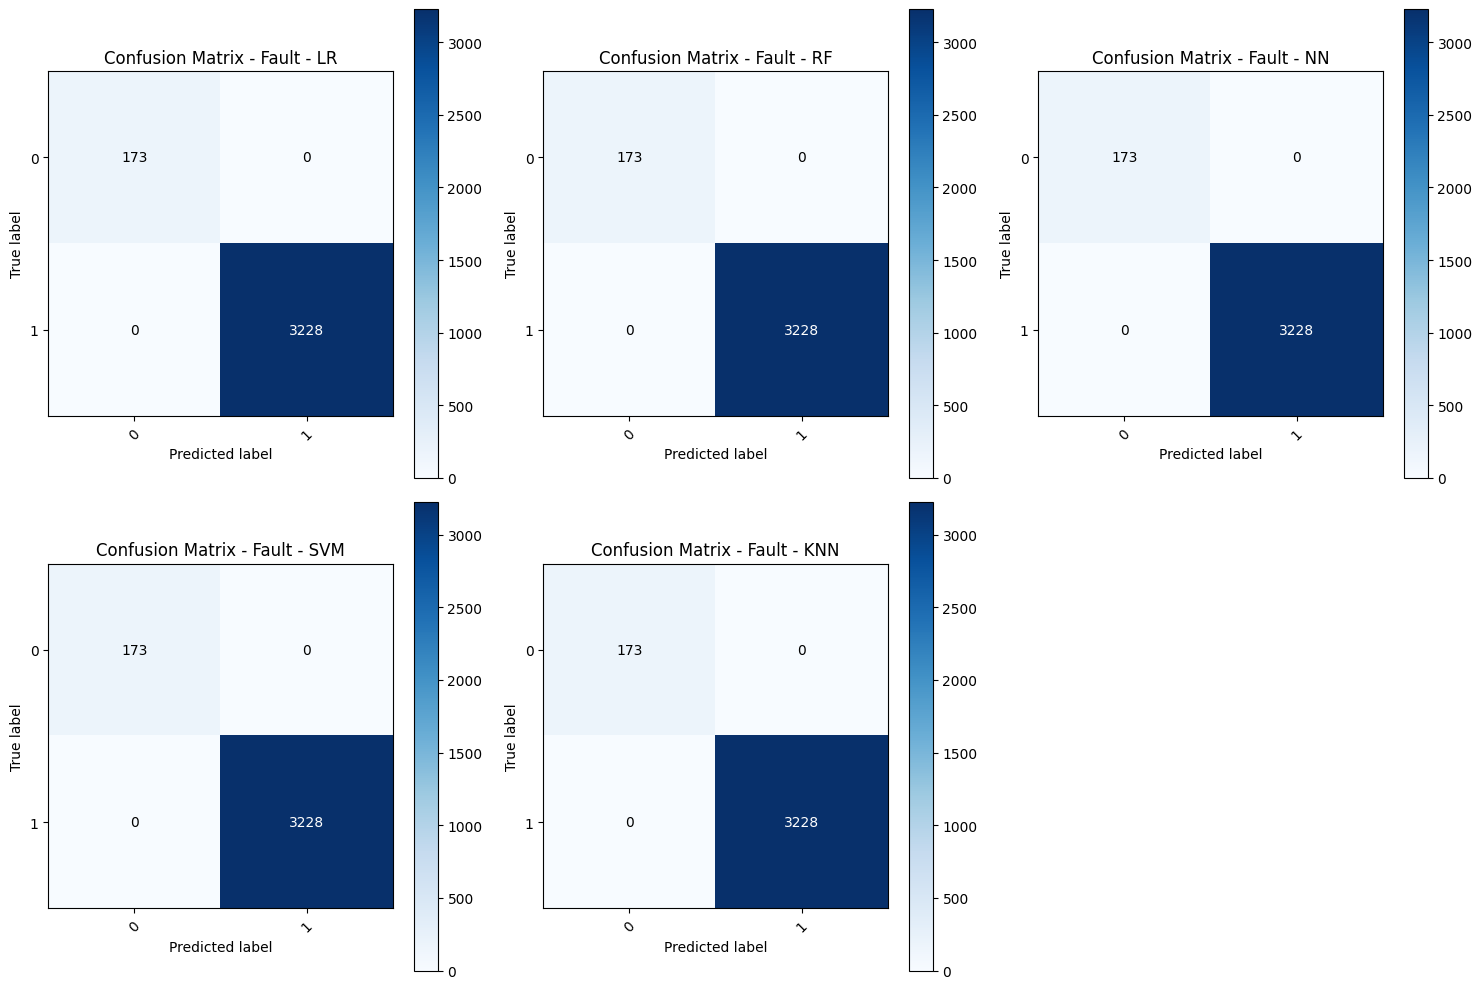

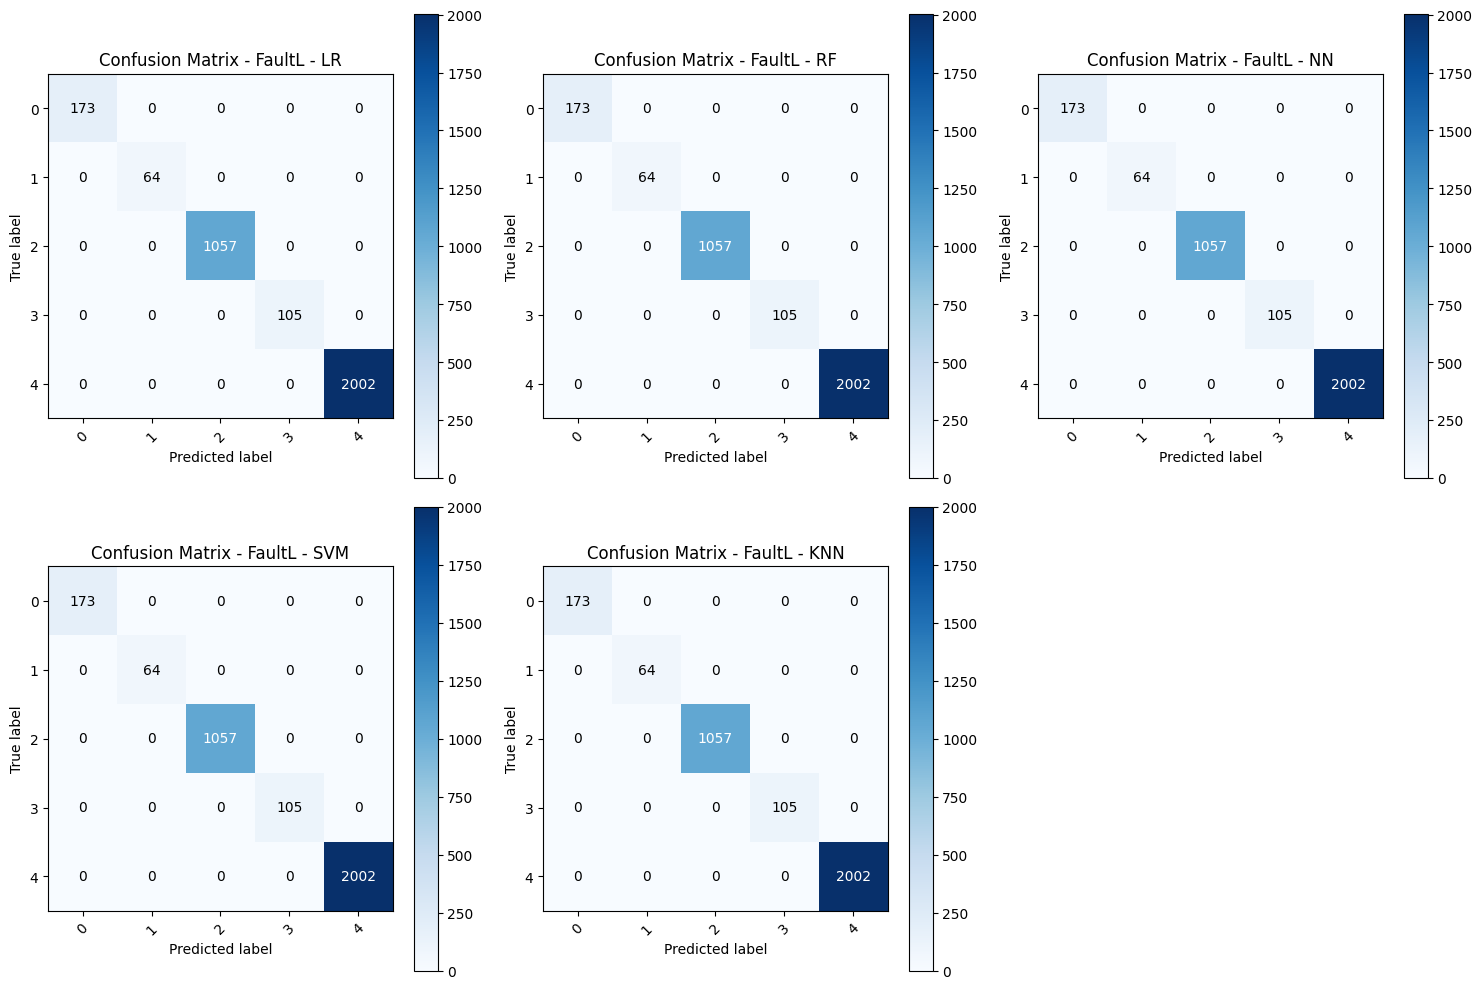

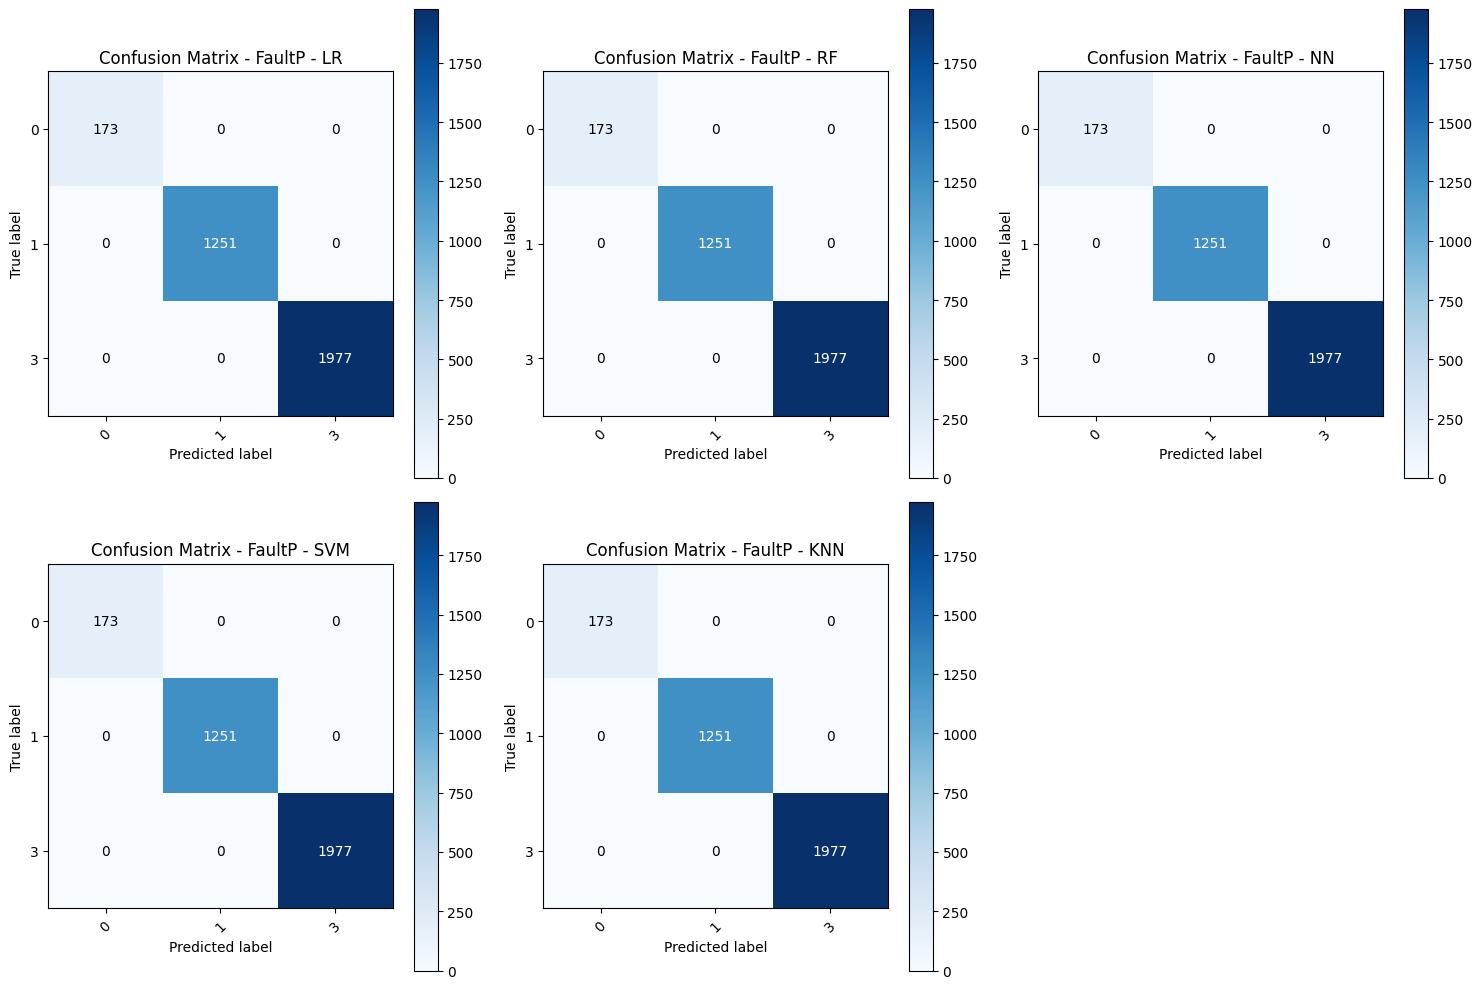

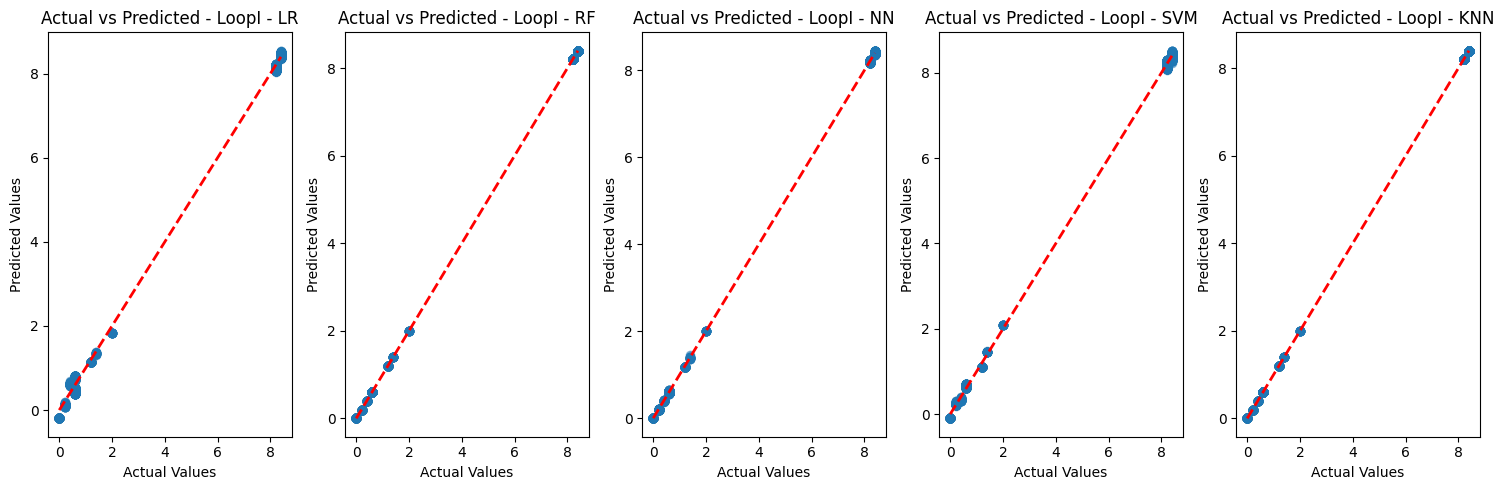


Classification Model Performance:

Fault Target:

LR Model:
Accuracy: 1.00
F1 Score: 1.00

RF Model:
Accuracy: 1.00
F1 Score: 1.00

NN Model:
Accuracy: 1.00
F1 Score: 1.00

SVM Model:
Accuracy: 1.00
F1 Score: 1.00

KNN Model:
Accuracy: 1.00
F1 Score: 1.00

FaultL Target:

LR Model:
Accuracy: 1.00
F1 Score: 1.00

RF Model:
Accuracy: 1.00
F1 Score: 1.00

NN Model:
Accuracy: 1.00
F1 Score: 1.00

SVM Model:
Accuracy: 1.00
F1 Score: 1.00

KNN Model:
Accuracy: 1.00
F1 Score: 1.00

FaultP Target:

LR Model:
Accuracy: 1.00
F1 Score: 1.00

RF Model:
Accuracy: 1.00
F1 Score: 1.00

NN Model:
Accuracy: 1.00
F1 Score: 1.00

SVM Model:
Accuracy: 1.00
F1 Score: 1.00

KNN Model:
Accuracy: 1.00
F1 Score: 1.00

Regression Model Performance:

LoopI Target:

LR Model:
Mean Squared Error: 0.01
R-squared: 1.00

RF Model:
Mean Squared Error: 0.00
R-squared: 1.00

NN Model:
Mean Squared Error: 0.00
R-squared: 1.00

SVM Model:
Mean Squared Error: 0.00
R-squared: 1.00

KNN Model:
Mean Squared Error: 0.00
R-squ

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from google.colab import drive
from joblib import load

def load_saved_models_and_data():
    """
    Load saved models, preprocessing objects, and feature names from Google Drive
    """
    drive.mount('/content/drive')

    try:
        # Load feature names and scaler
        feature_names = load('/content/drive/MyDrive/feature_names.joblib')
        scaler = load('/content/drive/MyDrive/scaler.joblib')

        # Load label encoders for classification targets
        label_encoders = {
            'Fault': load('/content/drive/MyDrive/label_encoder_Fault.joblib'),
            'FaultL': load('/content/drive/MyDrive/label_encoder_FaultL.joblib'),
            'FaultP': load('/content/drive/MyDrive/label_encoder_FaultP.joblib')
        }

        # Load classification models
        classification_models = {
            'Fault': {
                'lr': load('/content/drive/MyDrive/classification_lr_model_Fault.joblib'),
                'rf': load('/content/drive/MyDrive/classification_rf_model_Fault.joblib'),
                'nn': load('/content/drive/MyDrive/classification_nn_model_Fault.joblib'),
                'svm': load('/content/drive/MyDrive/classification_svm_model_Fault.joblib'),
                'knn': load('/content/drive/MyDrive/classification_knn_model_Fault.joblib')
            },
            'FaultL': {
                'lr': load('/content/drive/MyDrive/classification_lr_model_FaultL.joblib'),
                'rf': load('/content/drive/MyDrive/classification_rf_model_FaultL.joblib'),
                'nn': load('/content/drive/MyDrive/classification_nn_model_FaultL.joblib'),
                'svm': load('/content/drive/MyDrive/classification_svm_model_FaultL.joblib'),
                'knn': load('/content/drive/MyDrive/classification_knn_model_FaultL.joblib')
            },
            'FaultP': {
                'lr': load('/content/drive/MyDrive/classification_lr_model_FaultP.joblib'),
                'rf': load('/content/drive/MyDrive/classification_rf_model_FaultP.joblib'),
                'nn': load('/content/drive/MyDrive/classification_nn_model_FaultP.joblib'),
                'svm': load('/content/drive/MyDrive/classification_svm_model_FaultP.joblib'),
                'knn': load('/content/drive/MyDrive/classification_knn_model_FaultP.joblib')
            }
        }

        # Load regression models
        regression_models = {
            'LoopI': {
                'lr': load('/content/drive/MyDrive/regression_lr_model_LoopI.joblib'),
                'rf': load('/content/drive/MyDrive/regression_rf_model_LoopI.joblib'),
                'nn': load('/content/drive/MyDrive/regression_nn_model_LoopI.joblib'),
                'svm': load('/content/drive/MyDrive/regression_svm_model_LoopI.joblib'),
                'knn': load('/content/drive/MyDrive/regression_knn_model_LoopI.joblib')
            }
        }

        return feature_names, scaler, label_encoders, classification_models, regression_models

    except Exception as e:
        print(f"Error loading saved models: {str(e)}")
        return None, None, None, None, None

def load_original_data(file_path):
    """
    Load original dataset for evaluation
    """
    try:
        if file_path.endswith('.xlsx'):
            df = pd.read_excel(file_path)
        elif file_path.endswith('.csv'):
            df = pd.read_csv(file_path)
        else:
            raise ValueError("File must be either .xlsx or .csv")

        # Remove unnamed columns
        df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

        # Define target columns
        target_columns = ['Fault', 'FaultL', 'FaultP', 'LoopI']

        # Separate features and labels
        X = df.drop(columns=target_columns)
        y = df[target_columns]

        return X, y

    except Exception as e:
        print(f"Error loading data: {str(e)}")
        return None, None

def plot_confusion_matrices(X, y, feature_names, scaler, label_encoders, classification_models):
    """
    Plot confusion matrices for all classification models
    """
    X_scaled = scaler.transform(X)

    for target in ['Fault', 'FaultL', 'FaultP']:
        plt.figure(figsize=(15, 10))
        label_encoder = label_encoders[target]
        classes = label_encoder.classes_

        for i, (model_name, model) in enumerate(classification_models[target].items(), 1):
            plt.subplot(2, 3, i)
            y_pred = model.predict(X_scaled)
            cm = confusion_matrix(label_encoder.transform(y[target]), y_pred)

            plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
            plt.title(f'Confusion Matrix - {target} - {model_name.upper()}')
            plt.colorbar()

            tick_marks = np.arange(len(classes))
            plt.xticks(tick_marks, classes, rotation=45)
            plt.yticks(tick_marks, classes)

            thresh = cm.max() / 2.
            for r, c in np.ndindex(cm.shape):
                plt.text(c, r, format(cm[r, c], 'd'),
                         ha="center", va="center",
                         color="white" if cm[r, c] > thresh else "black")

            plt.ylabel('True label')
            plt.xlabel('Predicted label')

        plt.tight_layout()
        plt.show()

def plot_regression_results(X, y, feature_names, scaler, regression_models):
    """
    Plot actual vs predicted values for regression models
    """
    X_scaled = scaler.transform(X)

    plt.figure(figsize=(15, 5))

    for i, (model_name, model) in enumerate(regression_models['LoopI'].items(), 1):
        plt.subplot(1, 5, i)
        y_pred = model.predict(X_scaled)

        plt.scatter(y['LoopI'], y_pred, alpha=0.5)
        plt.plot([y['LoopI'].min(), y['LoopI'].max()],
                 [y['LoopI'].min(), y['LoopI'].max()], 'r--', lw=2)
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.title(f'Actual vs Predicted - LoopI - {model_name.upper()}')

    plt.tight_layout()
    plt.show()

def print_model_performance(X, y, feature_names, scaler, label_encoders, classification_models, regression_models):
    """
    Print performance metrics for all models
    """
    X_scaled = scaler.transform(X)

    # Classification performance
    print("\nClassification Model Performance:")
    for target in ['Fault', 'FaultL', 'FaultP']:
        print(f"\n{target} Target:")
        label_encoder = label_encoders[target]
        y_true = label_encoder.transform(y[target])

        for model_name, model in classification_models[target].items():
            y_pred = model.predict(X_scaled)
            accuracy = accuracy_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred, average='macro')

            print(f"\n{model_name.upper()} Model:")
            print(f"Accuracy: {accuracy:.2f}")
            print(f"F1 Score: {f1:.2f}")

    # Regression performance
    print("\nRegression Model Performance:")
    print("\nLoopI Target:")
    for model_name, model in regression_models['LoopI'].items():
        y_pred = model.predict(X_scaled)
        mse = mean_squared_error(y['LoopI'], y_pred)
        r2 = r2_score(y['LoopI'], y_pred)

        print(f"\n{model_name.upper()} Model:")
        print(f"Mean Squared Error: {mse:.2f}")
        print(f"R-squared: {r2:.2f}")

def main():
    # Path to your original dataset
    file_path = '/content/drive/MyDrive/Book6.xlsx'

    # Load saved models and original data
    feature_names, scaler, label_encoders, classification_models, regression_models = load_saved_models_and_data()
    X, y = load_original_data(file_path)

    if all([feature_names, scaler, label_encoders, classification_models, regression_models, X is not None, y is not None]):
        # Plot confusion matrices for classification models
        plot_confusion_matrices(X, y, feature_names, scaler, label_encoders, classification_models)

        # Plot regression results
        plot_regression_results(X, y, feature_names, scaler, regression_models)

        # Print model performance metrics
        print_model_performance(X, y, feature_names, scaler, label_encoders, classification_models, regression_models)
    else:
        print("Failed to load models or data.")

if __name__ == "__main__":
    main()